In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import scipy.stats as stats
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from scipy.stats import spearmanr

Dir_github = '/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI'
# Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
Dir_output = r'/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/sensitivity_lemma_mean'

/home/xy6/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
NFA = 8
df_FA_behav = pd.read_csv(os.path.join(Dir_output,f'df_FA8_behav_merged.csv'))
df_loadings = pd.read_csv(os.path.join(Dir_output,f'FA_n{NFA}_loadings.csv'))
List_106vars = list(df_loadings['index'])
List_FAs = [f'FA{x}' for x in range(1,NFA+1)]
List_Y = [x for x in df_FA_behav.columns if x.startswith('ACC') or x.startswith('RT') or x == 'Recog_Memory']

List_sort = ['RT_LD_V', 'RT_LD_A','RT_Naming','RT_SD', 
 'RT(3tasks)', 'RT(4tasks)',
 'ACC_LD_V', 'ACC_LD_A', 'ACC_Naming', 'ACC_SD', 'ACC_Recog',
 'ACC(3tasks)', 'ACC(4tasks)','ACC(5tasks)', 
]
    
dict_behav = {'RT_LD_V':['LexicalD_RT_V_ELP_z','LexicalD_RT_V_ECP_z','LexicalD_RT_V_BLP_z'],
                 'RT_LD_A':['LexicalD_RT_A_MALD_z','LexicalD_RT_A_AELP_z'],
                 'ACC_LD_V':['LexicalD_ACC_V_ELP','LexicalD_ACC_V_ECP','LexicalD_ACC_V_BLP'],
                 'ACC_LD_A':['LexicalD_ACC_A_MALD','LexicalD_ACC_A_AELP'],
                 'ACC_Naming':['Naming_ACC_ELP'],
                 'RT_Naming':['Naming_RT_ELP_z'],
                 'ACC_SD':['SemanticD_ACC_Calgary'],
                 'RT_SD':['SemanticD_RT_Calgary_z'],
                 'ACC_Recog':['Recog_Memory']}
dict_behav_combine = {'ACC(3tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming'],
                      'ACC(4tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming','ACC_SD'],
                      'ACC(5tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming','ACC_SD','ACC_Recog'],
                      'RT(3tasks)':['RT_LD_V','RT_LD_A','RT_Naming'],
                      'RT(4tasks)':['RT_LD_V','RT_LD_A','RT_Naming','RT_SD']}


options = {'List_FAs':List_FAs,'List_Y4':[],'List_Y5':[],
          'dict_behav':dict_behav,'dict_behav_combine':dict_behav_combine,
          'List_sort':List_sort}

# Figure1

In [ ]:
from matplotlib.patches import Rectangle
# plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(15,15))
df_corr = df_FA_behav[List_106vars].corr(method='spearman')
sns.heatmap(df_corr,cmap='vlag',vmin=-1,vmax=1,ax=ax,
            cbar_kws={'shrink': 0.4,},square=True) 

List_ticks = list(range(0,df_corr.shape[0]))
List_ticks = [x+0.5 for x in List_ticks]
ax.set_yticks(List_ticks)
List_ticks_labels = df_corr.index.to_list()
List_ticks_labels = [x.replace('_LemmaSum','') for x in List_ticks_labels]
ax.set_yticklabels(List_ticks_labels, fontsize=7)  # Set font size if needed
ax.set_xticks(List_ticks)
ax.set_xticklabels(List_ticks_labels, fontsize=7)  # Set font size if needed


### Add a square border
# rows, cols = df_corr.shape
# for idx_min,idx_max in [[0,20],[21,39],[40,47],[48,55],[56,66],[67,72],[73,76],[77,82]]:
#     idx_max = idx_max+1
#     side = idx_max-idx_min
#     rect = Rectangle((idx_min, idx_min), side, side, fill=False, color="black", linewidth=1)
#     ax.add_patch(rect)
# # fig.savefig(os.path.join(Dir_output,f'fig_corr_106vars_layout5_spearman.jpg'),bbox_inches="tight",dpi=300)

### Add a square border
rows, cols = df_corr.shape
rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
ax.add_patch(rect)

### remove cbar
# fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(24,24))
# sns.heatmap(df_corr,cmap='vlag',vmin=-1,vmax=1,ax=ax,
#             cbar=False,square=True) 

plt.show()
fig.savefig(os.path.join(Dir_output,f'Fig1_layout1.jpg'),bbox_inches="tight",dpi=300)


In [3]:
Dir_output

'/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/sensitivity_lemma_mean'

# Figure2

In [4]:


def spearman_corr_pvals(df):
    


    # Initialize empty matrices for results
    cols = df.columns
    n = len(cols)
    rho_matrix = np.zeros((n, n))
    p_matrix = np.zeros((n, n))

    # Compute pairwise Spearman correlation and p-values
    for i in range(n):
        for j in range(n):
            if i <= j:  # Compute only for upper triangle including diagonal
                rho, p = spearmanr(df[cols[i]], df[cols[j]])
                rho_matrix[i, j] = rho
                rho_matrix[j, i] = rho  # Mirror the value
                p_matrix[i, j] = p
                p_matrix[j, i] = p  # Mirror the value

    # Convert to DataFrame
    rho_df = pd.DataFrame(rho_matrix, index=cols, columns=cols)
    p_df = pd.DataFrame(p_matrix, index=cols, columns=cols)
    
    return rho_df,p_df

def r_to_FisherZ(r):
    """Convert correlation coefficient to Fisher's Z"""
    return 0.5 * np.log((1 + r) / (1 - r))
def FisherZ_to_z(FisherZ,N):
    SEz = 1/np.sqrt((N-3))
    z = FisherZ/SEz
    return(z)
def FisherZ_to_r(Z):
    """Convert Fisher's Z back to Spearman's r"""
    return (np.exp(2 * Z) - 1) / (np.exp(2 * Z) + 1)

def spearmanr_to_p(df):
    """Computes Spearman correlation matrix and p-value matrix"""
    cols = df.columns
    corr_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    pval_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            corr, pval = stats.spearmanr(df[cols[i]], df[cols[j]])
            corr_matrix.iloc[i, j] = corr
            pval_matrix.iloc[i, j] = pval
    
    return corr_matrix, pval_matrix
    
def z_to_p(z):
    """Convert a standard z-score to a two-tailed p-value."""
    return 2 * (1 - stats.norm.cdf(abs(z)))
def plot_screeplot(df_factors,ax):
 
    # Define the point (x1, y1) and slope a
    x1, y1 = 7, df_factors.loc[7,'ev']
    a = -1/3  # Change the slope as needed
    x_line = np.linspace(df_factors['idx'].min()-20, df_factors['idx'].max(), 100)
    y_line = a * (x_line - x1) + y1 -0.3

    sns.scatterplot(data=df_factors, x='idx', y='ev', s=10, ax=ax)
    ax.plot(x_line, y_line, label=f'Line with slope a={a}', color='gray',linestyle='--',linewidth=1)

    ax.set(xlabel='Factor Number', ylabel='Eigenvalue',xlim=[-2,106],ylim=[-2,22])


def plot_corrmap_FA(df_plot,ax,alpha = 0.05):
    dof = df_plot.shape[0] - 2 
    # alpha = 0.05  # Significance level (one-tailed)
    t_crit = stats.t.ppf(1 - alpha, dof)
    r_s_threshold = t_crit / (dof + t_crit**2)**0.5


    df_corr = df_plot.corr(method = 'spearman')
    df_corr_nan = df_corr.copy()
    df_corr_nan[(df_corr_nan<r_s_threshold)&((df_corr_nan>(-1*r_s_threshold)))]=np.nan
    # fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(6,6))
    ax = sns.heatmap(df_corr_nan.round(2),cmap='vlag',vmin=-1,vmax=1,square=True,ax=ax,
                    annot = True,
                    #cbar_kws={'shrink': 0.6,},
                    cbar=False,
                    annot_kws={"fontsize":8}

                    ) 
    ax.set(xlabel='',ylabel='')
     
    ### Add a square border
    rows, cols = df_corr_nan.shape
    rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
    ax.add_patch(rect)

def plot_corrmap_behav_avgfirst(df_FA_behav,ax,options,alpha = 0.05):
    List_FAs = options['List_FAs']
    List_Y4 = options['List_Y4']
    List_Y5 = options['List_Y5']

    df_Y4 = df_FA_behav[List_FAs+List_Y4].dropna().copy()
    df_corr_Y4 = df_Y4.corr(method='spearman').round(2)

    dof = df_Y4.shape[0] - 2 
    t_crit = stats.t.ppf(1 - alpha, dof)
    r_s_threshold_Y4 = t_crit / (dof + t_crit**2)**0.5

    df_corr_nan_Y4 = df_corr_Y4.copy()
    df_corr_nan_Y4[(df_corr_nan_Y4<r_s_threshold_Y4)&((df_corr_nan_Y4>(-1*r_s_threshold_Y4)))]=np.nan

    df_plot_Y4 = df_corr_nan_Y4.loc[List_FAs,List_Y4].T


    df_Y5 = df_FA_behav[List_FAs+List_Y5].dropna().copy()
    df_corr_Y5 = df_Y5.corr(method='spearman').round(2)

    dof = df_Y5.shape[0] - 2 
    t_crit = stats.t.ppf(1 - alpha, dof)
    r_s_threshold_Y5 = t_crit / (dof + t_crit**2)**0.5

    df_corr_nan_Y5 = df_corr_Y5.copy()
    df_corr_nan_Y5[(df_corr_nan_Y5<r_s_threshold_Y5)&((df_corr_nan_Y5>(-1*r_s_threshold_Y5)))]=np.nan

    df_plot_Y5 = df_corr_nan_Y5.loc[List_FAs,List_Y5].T

    df_plot = pd.concat([df_plot_Y4,df_plot_Y5.loc[['RT_SD','ACC_SD','ACC5','RT5']]])
    List_Y = ['RT_LD_V', 'RT_LD_A', 'RT_Naming','RT_SD','RT4','RT5',
            'ACC_LD_V', 'ACC_LD_A', 'ACC_Naming','Recog_Memory', 'ACC_SD', 'ACC4','ACC5']
    List_Y_label = ['RT_LD_V', 'RT_LD_A', 'RT_Naming','RT_SD','RT(4tasks)','RT(5tasks)',
              'ACC_LD_V', 'ACC_LD_A', 'ACC_Naming','ACC_Recog', 'ACC_SD', 'ACC(4tasks)','ACC(5tasks)']
         
    df_plot = df_plot.loc[List_Y]
    sns.heatmap(df_plot,vmin=-1,vmax=1,ax=ax,
                cmap='vlag',
                # xticklabels=[f'F{x}' for x in range(1,NFA+1)],
                yticklabels = List_Y_label,
                #square=True,
                    annot = True,
                    cbar_kws={'shrink': 0.6,},
                    cbar=False,
                    annot_kws={"fontsize":8}
                    ) 
 

    ### Add a square border
    rows, cols = df_plot.shape
    rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
    ax.add_patch(rect)

def plot_loadings(df_plot,ax):    
    heatmap = sns.heatmap(df_plot,ax=ax,cmap='vlag', vmin=-1,vmax=1, 
                #cbar_kws={'aspect': 50'use_gridspec':False,'location':"bottom",'orientation':"horizontal"},
                #bar_kws={'shrink': 0.2,},
                cbar=False,
                # linewidths=1,linecolor='black'
                )
    
    ax.set(xlabel='',ylabel='')


    List_ticks = list(range(0,df_plot.shape[0]))
    List_ticks = [x+0.5 for x in List_ticks]
    ax.set_yticks(List_ticks)
    List_ticks_labels = df_plot.index.to_list()
    List_ticks_labels = [x.replace('_LemmaSum','') for x in List_ticks_labels]
    ax.set_yticklabels(List_ticks_labels, fontsize=6)  # Set font size if needed


    ### Add a square border
    rows, cols = df_plot.shape
    rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
    ax.add_patch(rect)

def plot_corrmap_behav_rfirst(df_FA_behav,options,ax,r = 0):
    dict_behav = options['dict_behav']
    dict_behav_combine = options['dict_behav_combine']
    List_sort = options['List_sort']
    df_corr = pd.DataFrame(columns = List_FAs+['wordcount'])
    for var in dict_behav.keys():
        df_tmp = df_FA_behav[List_FAs+dict_behav[var]].dropna().copy()
        df_tmp_corr = df_tmp.corr(method='spearman').loc[dict_behav[var],List_FAs]
        df_tmp_corr['wordcount'] = df_tmp.shape[0]
        df_corr = pd.concat([df_corr,df_tmp_corr])
        df_corr.loc[var] = df_tmp.corr(method='spearman').loc[dict_behav[var],List_FAs].mean()
        # print(var,df_tmp.shape[0])
    for var in dict_behav_combine.keys():
        
        df_corr.loc[var] = df_corr.loc[dict_behav_combine[var]].mean()

    df_plot = df_corr.loc[List_sort].round(2)
    
    
    sns.heatmap(df_plot,vmin=-1,vmax=1,ax=ax,
                    cmap='vlag',
                    # xticklabels=[f'F{x}' for x in range(1,NFA+1)],
                    # yticklabels = List_Y_label,
                    #square=True,
                    # mask=df_plot.abs()<.1,
                    # vmin=-1,vmax=1,
                    annot = True,
                    cbar_kws={'shrink': 0.6,},
                    cbar=False,
                    annot_kws={"fontsize":8}
                    ) 
    
    
    ### Add a square border
    rows, cols = df_plot.shape
    rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
    ax.add_patch(rect)

    return(df_corr)

def calculate_rp(df_FA_behav):
    dict_behav = options['dict_behav']
    dict_behav_combine = options['dict_behav_combine']
        
    df_corr = pd.DataFrame(columns = List_FAs+['N'])
    df_p = pd.DataFrame(columns = List_FAs)
    # step1: calculate the r matrix
    for var1 in dict_behav.keys():
        for var2 in dict_behav[var1]:
            df_tmp = df_FA_behav[List_FAs+[var2]].dropna().copy()
            df_tmp_corr = df_tmp.corr(method='spearman').loc[var2,List_FAs]
            df_tmp_corr['N'] = df_tmp.shape[0]
            
            df_corr.loc[var2] = df_tmp_corr
    
            _,df_tmp_p = spearman_corr_pvals(df_tmp)
            df_p.loc[var2] = df_tmp_p.loc[var2,List_FAs]


def calculate_rp(df_FA_behav,method):
    dict_behav = options['dict_behav']
    dict_behav_combine = options['dict_behav_combine']
    List_FAs = options['List_FAs']
    
    df_corr = pd.DataFrame(columns = List_FAs+['N'])
    df_p = pd.DataFrame(columns = List_FAs)
    # step1: calculate the r matrix
    
    
    for var1 in dict_behav.keys():
        for var2 in dict_behav[var1]:
            df_tmp = df_FA_behav[List_FAs+[var2]].dropna().copy()
            
            if method == 'spearman_r':
                df_tmp_r,df_tmp_p = spearman_corr_pvals(df_tmp)
                df_corr.loc[var2] = df_tmp_r.loc[var2,List_FAs]
                df_p.loc[var2] = df_tmp_p.loc[var2,List_FAs]
                df_corr.loc[var2,'N'] = df_tmp.shape[0]
            elif method == 'spearman_partial_r':
                df_corr.loc[var2,'N'] = df_tmp.shape[0]
                for FAi in List_FAs:
                    List_covars = list(set(List_FAs)-set([FAi]))
                    partial_corr = pg.partial_corr(data=df_tmp, x=FAi, y=var2, covar=List_covars, method='spearman')
                    df_corr.loc[var2,FAi] = partial_corr['r'].values[0]
                    df_p.loc[var2,FAi] = partial_corr['p-val'].values[0]
    df_corr = df_corr.astype(float)
    return(df_corr,df_p)

def aggregate_hedges(df_FA_behav,options,method_r = 'spearman_partial_r',method_n = 'harmonic'):
    dict_behav = options['dict_behav']
    dict_behav_combine = options['dict_behav_combine']
    List_FAs = options['List_FAs']
    
    # step1: calculate the r matrix
    df_corr,df_p = calculate_rp(df_FA_behav,method=method_r)

    # step2: convert r to Fisher's z
    df_FisherZ = df_corr[List_FAs].map(r_to_FisherZ)
    df_FisherZ['N'] = df_corr['N']

    # step3: weighted average Fisher's z
    for var1 in dict_behav.keys():

        if len(dict_behav[var1])>1:
            for FAi in List_FAs:
                sum_wz = np.sum(df_FisherZ.loc[dict_behav[var1],FAi]*(df_FisherZ.loc[dict_behav[var1],'N']-3))
                sum_w = np.sum((df_FisherZ.loc[dict_behav[var1],'N']-3))
                fisherz = sum_wz/sum_w
                df_FisherZ.loc[var1,FAi] = fisherz
                
                if method_n == 'harmonic':
                    # harmonic mean can also be used (Lin and Chu, 2020), it will penalize the large sample size
                    df_FisherZ.loc[var1,'N'] = stats.hmean(df_FisherZ.loc[dict_behav[var1],'N'].values)
                elif method_n == 'arithmetic':
                # averaged sample size is used in (Hunter & Schmidt, 2004, p. 88)
                    df_FisherZ.loc[var1,'N'] = df_FisherZ.loc[dict_behav[var1],'N'].mean()


        else:
            df_FisherZ.loc[var1,List_FAs+['N']] = df_FisherZ.loc[dict_behav[var1],List_FAs+['N']].values

    for var in dict_behav_combine.keys():
        if len(dict_behav_combine[var])>1:
            for FAi in List_FAs:
                sum_wz = np.sum(df_FisherZ.loc[dict_behav_combine[var],FAi]*(df_FisherZ.loc[dict_behav_combine[var],'N']-3))
                sum_w = np.sum((df_FisherZ.loc[dict_behav_combine[var],'N']-3))
                fisherz = sum_wz/sum_w
                df_FisherZ.loc[var,FAi] = fisherz

                if method_n == 'harmonic':
                    # harmonic mean can also be used (Lin and Chu, 2020), it will penalize the large sample size
                    
                    df_FisherZ.loc[var,'N'] = stats.hmean(df_FisherZ.loc[dict_behav_combine[var],'N'].values)
                elif method_n == 'arithmetic':
                    # averaged sample size is used in (Hunter & Schmidt, 2004, p. 88)
                    df_FisherZ.loc[var,'N'] = df_FisherZ.loc[dict_behav_combine[var],'N'].mean() 
        else:
            df_FisherZ.loc[var,List_FAs+['N']] = df_FisherZ.loc[dict_behav_combine[var],List_FAs+['N']].values

    # step4: convert Fisher's z back to r
    df_corr_agg = df_FisherZ.loc[list(dict_behav.keys())+list(dict_behav_combine.keys()),List_FAs].map(FisherZ_to_r)
    df_corr_agg['N'] = df_FisherZ.loc[list(dict_behav.keys())+list(dict_behav_combine.keys()),'N']
    df_corr = pd.concat([df_corr,df_corr_agg])


    # step4: Fisher's z to standard z
    df_z = df_FisherZ.loc[list(dict_behav.keys())+list(dict_behav_combine.keys())].apply(lambda row: FisherZ_to_z(row[List_FAs], row['N']), axis=1)

    # step5: get the p matrix
    df_p = pd.concat([df_p,df_z.map(z_to_p)])

    return(df_corr,df_p)

def plot_corrmap_behav(df_corr,df_p,options,ax,thresh = 0):
    dict_behav = options['dict_behav']
    dict_behav_combine = options['dict_behav_combine']
    List_FAs = options['List_FAs']
    
#     
    
    # plot
    List_sort = options['List_sort']

    df_plot = df_corr.loc[List_sort,List_FAs].round(2)
    df_plot_p = df_p.loc[List_sort,List_FAs]
    # fig,ax=plt.subplots()
    
    sns.heatmap(df_plot,vmin=-1,vmax=1,ax=ax,
                    cmap='vlag',
                    # xticklabels=[f'F{x}' for x in range(1,NFA+1)],
                    # yticklabels = List_Y_label,
                    #square=True,
                    mask=df_plot_p.values>=thresh,
                    # vmin=-1,vmax=1,
                    annot = True,
                    cbar_kws={'shrink': 0.6,},
                    cbar=False,
                    annot_kws={"fontsize":8}
                    ) 
    
    
    ### Add a square border
    rows, cols = df_plot.shape
    rect = Rectangle((0, 0), cols,rows, fill=False, color="black", linewidth=2)
    ax.add_patch(rect)
    return(df_corr,df_p)

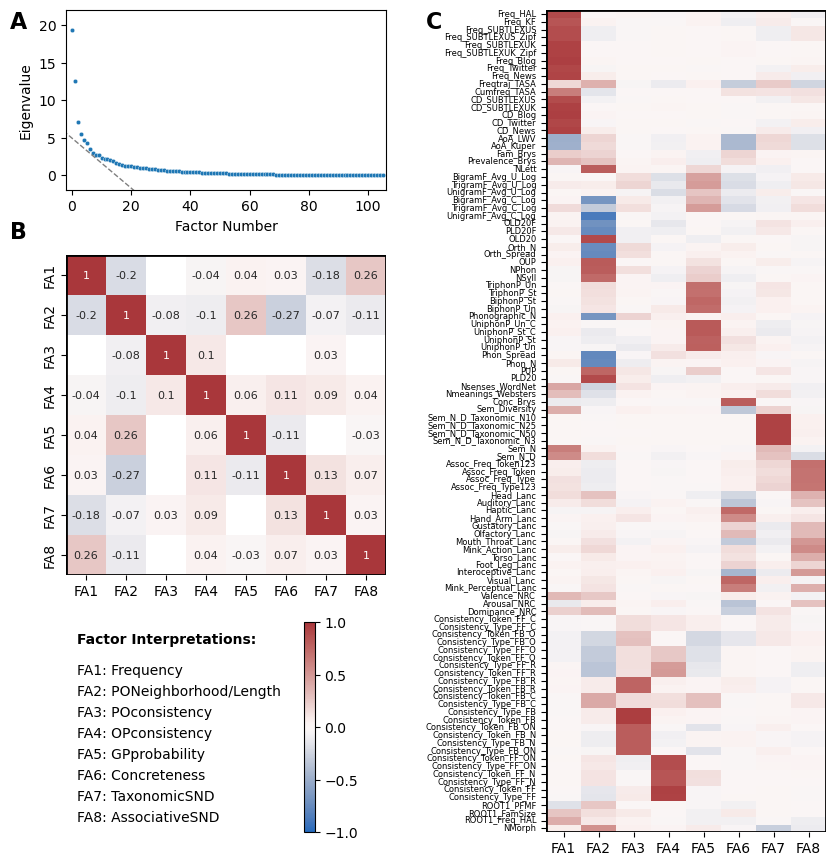

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg

alpha = 0.001

height_c, width_c = [0.35,0.35]
left_c = 0
right_c = left_c+width_c
bottom_c = 0
top_c = bottom_c+height_c

fig = plt.figure(figsize=(8, 6))
gs_C = fig.add_gridspec(nrows=1, ncols=1, left=left_c, right=right_c, bottom=bottom_c, top=top_c)
ax_C = fig.add_subplot(gs_C[0]) 
df_corr_FA = aggregate_hedges(df_FA_behav,options,method_r = 'spearman_partial_r',method_n = 'harmonic')


cmap = sns.color_palette("vlag", as_cmap=True)  # Converts 'vlag' to a Matplotlib colormap

norm = mcolors.Normalize(vmin=-1, vmax=1) 
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for colorbar

cbar = fig.colorbar(sm, ax=ax_C)

ax_C.text(x=0.05,y=0.9,s='Factor Interpretations:',fontweight='bold')
for i,label in enumerate(['FA1: Frequency',
                          'FA2: PONeighborhood/Length',
                          'FA3: POconsistency',
                          'FA4: OPconsistency',
                          'FA5: GPprobability',
                          'FA6: Concreteness',
                          'FA7: TaxonomicSND',
                          'FA8: AssociativeSND']):
    ax_C.text(x=0.05,y=0.75-i*0.1,s=label)
ax_C.axis('off')

### 
height_b, width_b = [0.55,0.4]
left_b = 0
right_b = left_b+width_b
bottom_b = top_c+0.07
top_b = bottom_b+height_b
gs_B = fig.add_gridspec(nrows=1, ncols=1, left=left_b, right=right_b, bottom=bottom_b, top=top_b)
ax_B = fig.add_subplot(gs_B[0]) 
df_plot = df_FA_behav[List_FAs].copy()
plot_corrmap_FA(df_plot,ax_B,alpha = alpha)

height_a, width_a = [0.3,0.4]
left_a = 0
right_a = left_a+width_a
bottom_a = top_b+0.1
top_a = bottom_a+height_a
gs_A = fig.add_gridspec(nrows=1, ncols=1, left=left_a, right=right_a, bottom=bottom_a, top=top_a)
ax_A = fig.add_subplot(gs_A[0]) 
df_factors = pd.read_csv(os.path.join(Dir_output,'df_factorloadings_eigenvalues.csv'))
plot_screeplot(df_factors,ax_A)

gs_D = fig.add_gridspec(nrows=1, ncols=1, left=0.6, right=0.95, bottom=0, top=top_a)
ax_D = fig.add_subplot(gs_D[0])  
df_loadings = pd.read_csv(os.path.join(Dir_output,f'FA_n{NFA}_loadings_full.csv'))
# df_loadings = pd.read_csv(os.path.join(Dir_output,f'FA_n{NFA}_loadings.csv'))
df_plot = df_loadings.set_index('index').dropna(how='all').copy()
df_plot.columns = List_FAs
plot_loadings(df_plot,ax_D)

fig.text(x=-0.07,y=1.34,s='A', fontsize=16, fontweight='bold')
fig.text(x=-0.07,y=0.99,s='B', fontsize=16, fontweight='bold')
# fig.text(x=-0.07,y=0.42-0.05,s='C', fontsize=16, fontweight='bold')
fig.text(x=0.45,y=1.34,s='C', fontsize=16, fontweight='bold')




plt.show()
# fig.savefig(os.path.join(Dir_output,f'Fig2_fisherz_{str(alpha)[2:]}.jpg'),bbox_inches="tight",dpi=300)
fig.savefig(os.path.join(Dir_output,f'Fig2_fisherz_partial_hedges_{str(alpha)[2:]}_layout4.jpg'),bbox_inches="tight",dpi=300)


Figure 3

In [ ]:
dict_behav = {'RT_LD_V':['LexicalD_RT_V_ELP_z','LexicalD_RT_V_ECP_z','LexicalD_RT_V_BLP_z'],
                 'RT_LD_A':['LexicalD_RT_A_MALD_z','LexicalD_RT_A_AELP_z'],
                 'ACC_LD_V':['LexicalD_ACC_V_ELP','LexicalD_ACC_V_ECP','LexicalD_ACC_V_BLP'],
                 'ACC_LD_A':['LexicalD_ACC_A_MALD','LexicalD_ACC_A_AELP'],
                 'ACC_Naming':['Naming_ACC_ELP'],
                 'RT_Naming':['Naming_RT_ELP_z'],
                 'ACC_SD':['SemanticD_ACC_Calgary'],
                 'RT_SD':['SemanticD_RT_Calgary_z'],
                 'ACC_Recog':['Recog_Memory']
             }
dict_behav_combine = {'ACC(3tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming'],
                      'ACC(4tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming','ACC_SD'],
                      'ACC(5tasks)':['ACC_LD_V','ACC_LD_A','ACC_Naming','ACC_SD','ACC_Recog'],
                      'RT(3tasks)':['RT_LD_V','RT_LD_A','RT_Naming'],
                      'RT(4tasks)':['RT_LD_V','RT_LD_A','RT_Naming','RT_SD']}

List_sort = ['RT_LD_V', 'RT_LD_A','RT_Naming','RT_SD', 
     'RT(3tasks)', 'RT(4tasks)',
     'ACC_LD_V', 'ACC_LD_A', 'ACC_Naming','ACC_SD',  'ACC_Recog',
     'ACC(3tasks)', 'ACC(4tasks)','ACC(5tasks)',
    ]
options = {'List_FAs':List_FAs,'List_Y4':[],'List_Y5':[],
          'dict_behav':dict_behav,'dict_behav_combine':dict_behav_combine,
          'List_sort':List_sort}

alpha = 0.001
fig = plt.figure(figsize=(8, 6))


height_a, width_a = [0.35,0.4]
left_a = 0
right_a = left_a+width_a
bottom_a = 0
top_a = bottom_a+height_a
gs_A = fig.add_gridspec(nrows=1, ncols=1, left=left_a, right=right_a, bottom=bottom_a, top=top_a)
ax_A = fig.add_subplot(gs_A[0]) 
df_corr_FA = aggregate_hedges(df_FA_behav,options,method_r = 'spearman_r',method_n = 'harmonic')

plot_corrmap_behav(df_corr_FA[0],df_corr_FA[1],options,ax_A,thresh=0.001)
ax_A.set_title('Spearman Correlations')



###
height_c, width_c = [0.35,0.5]
left_c = right_a+0.05
right_c = left_c+width_c
bottom_c = 0
top_c = bottom_c+height_c


gs_C = fig.add_gridspec(nrows=1, ncols=1, left=left_c, right=right_c, bottom=bottom_c, top=top_c)
ax_C = fig.add_subplot(gs_C[0]) 
df_corr_FA = aggregate_hedges(df_FA_behav,options,method_r = 'spearman_partial_r',method_n = 'harmonic')

plot_corrmap_behav(df_corr_FA[0],df_corr_FA[1],options,ax_C,thresh=0.001)
ax_C.set_yticklabels([])
ax_C.set_title('Spearman Partial Correlations')

fig.text(x=-0.05,y=0.37,s='A',fontweight='bold',fontsize=16)
fig.text(x=0.41,y=0.37,s='B',fontweight='bold',fontsize=16)

fig.text(x=0.32,y=-0.078,s='Factor Interpretations:',fontweight='bold')
for i,label in enumerate(['FA1: Frequency',
                          'FA2: PONeighborhood/Length',
                          'FA3: POconsistency',
                          'FA4: OPconsistency']
                        ):
    fig.text(x=0.18,y=-0.12-i*0.03,s=label)
    
for i,label in enumerate(['FA5: GPprobability',
                          'FA6: Concreteness',
                          'FA7: TaxonomicSND',
                          'FA8: AssociativeSND']):
    fig.text(x=0.51,y=-0.12-i*0.03,s=label)

    
    
# 
cmap = sns.color_palette("vlag", as_cmap=True)  # Converts 'vlag' to a Matplotlib colormap
norm = mcolors.Normalize(vmin=-1, vmax=1) 
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for colorbar

cbar = fig.colorbar(sm, ax=ax_C)

plt.show()
fig.savefig(os.path.join(Dir_output,f'Fig3_fisherz_partial_hedges_{str(alpha)[2:]}_layout5.jpg'),bbox_inches="tight",dpi=300)
